# 🎯 Pipeline FPD — Hackathon TMB × PIT (v3 — corrigido)

## Melhorias da v3 (vs. v2)

| # | Correção | Por quê |
|---|----------|---------|
| 1 | **Base completa** (sem `nrows=5000`) | v2 treinava em 5% dos dados |
| 2 | **Universo comum de colunas** treino ∩ submissão | Evita zerar bureau na submissão |
| 3 | **Limpeza de linhas corrompidas** (asserts de sanidade) | Remove ~45 linhas com colunas deslocadas |
| 4 | **`endereco_estado` → 27 UFs + OUTRO** | Reduz de 240+ dummies para 28 |
| 5 | **Frequency encoding pós-split** | Elimina leakage sutil |
| 6 | **Optuna otimiza PR-AUC** (não ROC-AUC) | Mentores priorizam Precision |
| 7 | **Threshold ótimo via PR-curve** (target Prec≥70%) | Mentores: <60% baixo, ~70% bom, >75% excelente |
| 8 | **Faixas por quantis (P20/P60/P85)** | v2 só gerava 2 faixas; agora 4 reais |
| 9 | **Calibração isotônica** | Probabilidade vira ação → tem que ser calibrada |
| 10 | **Asserts de sanidade** em vários pontos | Robustez/reprodutibilidade |


## 1️⃣ Imports e configuração

In [ ]:
# Instale o que faltar com:
#   pip install pandas numpy scikit-learn xgboost lightgbm imbalanced-learn optuna matplotlib seaborn scipy openpyxl

import pandas as pd
import numpy as np
import re
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, fbeta_score, precision_score, recall_score,
                              confusion_matrix, roc_curve, precision_recall_curve)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from scipy.stats import ks_2samp

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', None)
print('✅ Bibliotecas carregadas')


✅ Bibliotecas carregadas


## 2️⃣ Carregamento dos dados

In [ ]:
# Carrega TREINO e SUBMISSÃO já neste passo:
# precisamos saber o universo comum de colunas para não treinar com features
# que não existem na submissão (e vice-versa).

ARQUIVO_TREINO = 'basetreinamento.xlsx'
ARQUIVO_SUB    = 'submissao.xlsx'

df  = pd.read_excel(ARQUIVO_TREINO)
df_sub_raw = pd.read_excel(ARQUIVO_SUB)

print(f'Treino:    {df.shape}')
print(f'Submissão: {df_sub_raw.shape}')

# Diferenças
treino_cols = set(df.columns)
sub_cols    = set(df_sub_raw.columns)
print(f'\nSó em TREINO ({len(treino_cols-sub_cols)}):    {sorted(treino_cols - sub_cols)}')
print(f'Só em SUBMISSÃO ({len(sub_cols-treino_cols)}): {sorted(sub_cols - treino_cols)}')

# UNIVERSO COMUM: features presentes em ambos + FPD (só no treino)
COMMON_COLS = (treino_cols & sub_cols) | {'FPD'}
print(f'\n✅ Universo comum + FPD: {len(COMMON_COLS)} colunas')


Treino:    (99999, 56)
Submissão: (23354, 56)

Só em TREINO (11):    ['CPF', 'FPD', 'H5OR', 'HCR5', 'HI01_CONCEITO', 'HI01_PROB', 'HPG5', 'SCORE_HCP5', 'SCORE_HFI5', 'SCORE_HSV5', 'SCORE_HVA5']
Só em SUBMISSÃO (11): ['HI02_CONCEITO', 'HI02_PROB', 'SCORE_H5OR', 'SCORE_HCC4', 'SCORE_HCMV', 'SCORE_HCR4', 'SCORE_HIRF', 'SCORE_HPG5', 'SCORE_HRCP', 'Vencimento', 'documento2']

✅ Universo comum + FPD: 46 colunas


## 3️⃣ Limpeza: remoção de leakage

> Regra inegociável do desafio: o modelo deve usar apenas informações disponíveis no momento do checkout.


In [ ]:
# 1) Colunas pós-evento — LEAKAGE
LEAKAGE_COLS = [
    'status_cobranca', 'status_financeiro', 'status_pedido',
    'saldo_vencido', 'quantidade_parcelas_vencidas', 'recebido',
    'primeiro_vencimento_em_atraso', 'dias_em_atraso', 'pdd',
    'saldo_vencido_com_juros', 'total_pago_com_juros',
    'aguardando_pagamento_sem_juros', 'vencidos_sem_juros_tmb',
    'recebido_sem_juros_tmb', 'data_quitacao',
]

# 2) Identificadores / PII
ID_COLS = [
    'pedido_id', 'CPF', 'documento', 'documento2', 'nome', 'email',
    'telefone_ativo', 'endereco_cep', 'endereco_cidade', 'pedido_pai_ob',
    'Vencimento',  # data pós-checkout que não está no treino
]

# Aplicar apenas o universo comum + FPD, depois remover leakage/IDs
df = df[[c for c in df.columns if c in COMMON_COLS]].copy()

cols_to_drop = [c for c in (LEAKAGE_COLS + ID_COLS) if c in df.columns]
df_clean = df.drop(columns=cols_to_drop).copy()

# --- LIMPEZA DE LINHAS CORROMPIDAS ---
# Asserts de sanidade: idade, total_financiado, quantidade_parcelas
# Esses ranges são generosos — só pegam linhas claramente deslocadas
def _to_num(s):
    return pd.to_numeric(s, errors='coerce')

idade_num  = _to_num(df_clean.get('idade'))
total_num  = _to_num(df_clean.get('total_financiado'))
parc_num   = _to_num(df_clean.get('quantidade_parcelas'))

mask_ok = pd.Series(True, index=df_clean.index)
if idade_num is not None:
    mask_ok &= idade_num.between(16, 100) | idade_num.isna()
if total_num is not None:
    mask_ok &= total_num.between(10, 1_000_000) | total_num.isna()
if parc_num is not None:
    mask_ok &= parc_num.between(1, 60) | parc_num.isna()

n_removidas = int((~mask_ok).sum())
df_clean = df_clean[mask_ok].reset_index(drop=True)
# IMPORTANTE: manter df alinhado com df_clean para o map_fpd da próxima célula
df = df.loc[mask_ok.index[mask_ok]].reset_index(drop=True)

print(f'🗑️  Removidas {len(cols_to_drop)} colunas: {cols_to_drop}')
print(f'🧹 Removidas {n_removidas} linhas corrompidas')
print(f'📉 Shape após limpeza: {df_clean.shape}')


🗑️  Removidas 23 colunas: ['status_cobranca', 'status_financeiro', 'status_pedido', 'saldo_vencido', 'quantidade_parcelas_vencidas', 'recebido', 'primeiro_vencimento_em_atraso', 'dias_em_atraso', 'pdd', 'saldo_vencido_com_juros', 'total_pago_com_juros', 'aguardando_pagamento_sem_juros', 'vencidos_sem_juros_tmb', 'recebido_sem_juros_tmb', 'data_quitacao', 'pedido_id', 'documento', 'nome', 'email', 'telefone_ativo', 'endereco_cep', 'endereco_cidade', 'pedido_pai_ob']
🧹 Removidas 50 linhas corrompidas
📉 Shape após limpeza: (99949, 23)


## 4️⃣ Target FPD

In [ ]:
def map_fpd(v):
    s = str(v).strip().lower()
    if 'sim' in s or s == 's' or s == '1':
        return 1
    return 0

df_clean['FPD'] = df['FPD'].apply(map_fpd).astype(int)
print(df_clean['FPD'].value_counts())
print(f'Taxa positiva: {df_clean["FPD"].mean():.2%}')

FPD
0    86091
1    13858
Name: count, dtype: int64
Taxa positiva: 13.87%


## 5️⃣ Feature engineering

- `idade`: alguns vêm como número, outros como data → padronizar
- `data_efetivacao`: extrair mês/dia/dow + manter para split temporal
- `produtor`, `lancamento`: alta cardinalidade → **frequency encoding**
- Categóricas com poucas classes → one-hot com `dummy_na=True`


In [ ]:
hoje = datetime.today()

def fix_idade(v):
    if pd.isna(v): return np.nan
    if isinstance(v, (int, float)): return float(v)
    if isinstance(v, (datetime, pd.Timestamp)):
        return (hoje - v).days // 365
    return np.nan

df_clean['idade'] = df_clean['idade'].apply(fix_idade)
df_clean['idade'] = pd.to_numeric(df_clean['idade'], errors='coerce')
df_clean['idade'] = df_clean['idade'].clip(16, 95)   # outliers de idade

if 'nascimento' in df_clean.columns:
    nasc = pd.to_datetime(df_clean['nascimento'], errors='coerce')
    df_clean['idade'] = df_clean['idade'].fillna((hoje - nasc).dt.days // 365)
    df_clean = df_clean.drop(columns=['nascimento'])

df_clean['idade'] = pd.to_numeric(df_clean['idade'], errors='coerce').clip(16, 95)

# Data e hora da compra
df_clean['data_efetivacao'] = pd.to_datetime(df_clean['data_efetivacao'], errors='coerce')
df_clean['hora_compra'] = df_clean['data_efetivacao'].dt.hour

def periodo_do_dia(h):
    if pd.isna(h): return 'desconhecido'
    if 0 <= h < 6:   return 'madrugada'
    if 6 <= h < 12:  return 'manha'
    if 12 <= h < 18: return 'tarde'
    return 'noite'

df_clean['periodo_compra'] = df_clean['hora_compra'].apply(periodo_do_dia)
df_clean['compra_noturna'] = ((df_clean['hora_compra'] >= 22) |
                               (df_clean['hora_compra'] < 6)).astype(int)
df_clean['data_efetivacao'] = df_clean['data_efetivacao'].dt.normalize()

for c in ['total_financiado', 'quantidade_parcelas', 'score']:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

if 'categoria_risco_score' in df_clean.columns:
    df_clean = df_clean.drop(columns=['categoria_risco_score'])

# --- endereço_estado: limitar a 27 UFs + OUTRO ---
UFS = {'AC','AL','AP','AM','BA','CE','DF','ES','GO','MA','MT','MS','MG',
       'PA','PB','PR','PE','PI','RJ','RN','RS','RO','RR','SC','SP','SE','TO'}
if 'endereco_estado' in df_clean.columns:
    df_clean['endereco_estado'] = (df_clean['endereco_estado']
        .astype(str).str.strip().str.upper().str[:2]
        .where(lambda x: x.isin(UFS), 'OUTRO'))

# NÃO faz frequency encoding aqui — será feito DEPOIS do split temporal
# Apenas mantemos produtor/lancamento como string por enquanto

cat_cols = [c for c in ['segmento', 'modalidade', 'MENSAGEM_TIPO_REGISTRO',
                          'endereco_estado', 'order_bump', 'periodo_compra']
            if c in df_clean.columns]
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True, dummy_na=True)
df_clean.columns = [re.sub(r'[^\w]', '_', c) for c in df_clean.columns]

# Sanity check: nº de dummies de estado deve ser <= 28 (27 UFs + OUTRO, drop_first reduz para 27)
est_dummies = [c for c in df_clean.columns if c.startswith('endereco_estado_')]
print(f'🌎 Dummies de estado: {len(est_dummies)} (esperado ≤ 28)')
assert len(est_dummies) <= 28, f'Estado ainda com {len(est_dummies)} dummies — limpeza falhou'

print(f'✅ Shape após FE: {df_clean.shape}')
print(f'NaT em data_efetivacao: {df_clean["data_efetivacao"].isna().sum()}')


🌎 Dummies de estado: 28 (esperado ≤ 28)
✅ Shape após FE: (99949, 64)
NaT em data_efetivacao: 0


## 6️⃣ Split TEMPORAL 


- **80% mais antigos** → treino
- **20% mais recentes** → teste 


In [ ]:
df_clean = df_clean.dropna(subset=['data_efetivacao']).reset_index(drop=True)
df_clean = df_clean.sort_values('data_efetivacao').reset_index(drop=True)
corte = int(len(df_clean) * 0.8)

print(f'📅 Treino: {df_clean["data_efetivacao"].iloc[:corte].min()} → {df_clean["data_efetivacao"].iloc[:corte].max()}')
print(f'📅 Teste:  {df_clean["data_efetivacao"].iloc[corte:].min()} → {df_clean["data_efetivacao"].iloc[corte:].max()}')

train_df = df_clean.iloc[:corte].drop(columns=['data_efetivacao']).copy()
test_df  = df_clean.iloc[corte:].drop(columns=['data_efetivacao']).copy()

# --- FREQUENCY ENCODING (pós-split) ---
# Calcula no TREINO; aplica no TREINO e no TESTE; novos valores no teste viram 0
FREQ_MAPS = {}
for col in ['produtor', 'lancamento']:
    if col in train_df.columns:
        freq = train_df[col].value_counts(normalize=True)
        FREQ_MAPS[col] = freq
        train_df[col + '_freq'] = train_df[col].map(freq).fillna(0.0)
        test_df[col + '_freq']  = test_df[col].map(freq).fillna(0.0)
        train_df = train_df.drop(columns=[col])
        test_df  = test_df.drop(columns=[col])

# Qualquer object remanescente: derruba
obj_cols_tr = train_df.select_dtypes(include='object').columns.tolist()
if obj_cols_tr:
    print(f'⚠️  Removendo objects remanescentes no treino: {obj_cols_tr}')
    train_df = train_df.drop(columns=obj_cols_tr)
    test_df  = test_df.drop(columns=[c for c in obj_cols_tr if c in test_df.columns])

y_train = train_df['FPD'].astype(int); X_train = train_df.drop(columns=['FPD'])
y_test  = test_df['FPD'].astype(int);  X_test  = test_df.drop(columns=['FPD'])

# Sanity: X_test deve ter exatamente as mesmas colunas de X_train, na mesma ordem
assert set(X_train.columns) == set(X_test.columns), 'Colunas treino/teste divergem'
X_test = X_test[X_train.columns]

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

print(f'\n✅ X_train: {X_train.shape}, taxa FPD: {y_train.mean():.2%}')
print(f'✅ X_test:  {X_test.shape}, taxa FPD: {y_test.mean():.2%}')
print(f'✅ {len(X_train.columns)} features finais')


📅 Treino: 2023-08-01 00:00:00 → 2024-01-25 00:00:00
📅 Teste:  2024-01-25 00:00:00 → 2025-07-31 00:00:00

✅ X_train: (79959, 62), taxa FPD: 14.35%
✅ X_test:  (19990, 62), taxa FPD: 11.94%
✅ 62 features finais


## 7️⃣ Funções de avaliação

| Métrica | Por que importa |
|---|---|
| **ROC-AUC** | Ranqueamento; métrica oficial do hackathon |
| **PR-AUC** | Melhor que ROC quando a classe positiva é rara |
| **KS** | Clássica em crédito: separação entre bons e maus |
| **F1** | Balanço precisão/recall no threshold default |
| **Recall top-10%/20%** | Responde "quanto FPD capturo nos N% piores?" |


In [ ]:
def ks_statistic(y_true, y_proba):
    return ks_2samp(y_proba[y_true == 1], y_proba[y_true == 0]).statistic

def top_q_recall(y_true, y_proba, q=0.10):
    n_top = max(int(len(y_proba) * q), 1)
    idx_top = np.argsort(-y_proba)[:n_top]
    return y_true.iloc[idx_top].sum() / max(y_true.sum(), 1)

def evaluate_model(model, X_te, y_te, threshold=0.5, proba=None):
    if proba is None:
        proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        'ROC_AUC': roc_auc_score(y_te, proba),
        'PR_AUC':  average_precision_score(y_te, proba),
        'KS':      ks_statistic(y_te.values, proba),
        'F1':      f1_score(y_te, pred),
        'F0.5':    fbeta_score(y_te, pred, beta=0.5),  # favorece precision
        'Precision': precision_score(y_te, pred, zero_division=0),
        'Recall':  recall_score(y_te, pred),
        'Top10%':  top_q_recall(y_te, proba, 0.10),
        'Top20%':  top_q_recall(y_te, proba, 0.20),
    }


## 8️⃣ Estratégias de balanceamento

⚠️ **Resampling SÓ no treino. Nunca no teste.**

| Estratégia | Quando usar |
|---|---|
| baseline | sem tratamento; referência |
| class_weight | barato e eficaz; mantém tamanho dos dados |
| SMOTE | oversampling sintético via k-NN |
| ADASYN | foca em pontos difíceis da fronteira |
| RandomUnderSampler | reduz a maioria; rápido mas perde dados |
| SMOTEENN | oversampling + limpeza de ruído |


In [ ]:
def get_resampled(strategy, X, y, seed=SEED):
    if strategy in ('baseline', 'class_weight'):
        return X, y
    if strategy == 'SMOTE':
        return SMOTE(random_state=seed, k_neighbors=5).fit_resample(X, y)
    if strategy == 'ADASYN':
        return ADASYN(random_state=seed, n_neighbors=5).fit_resample(X, y)
    if strategy == 'UnderSample':
        return RandomUnderSampler(random_state=seed).fit_resample(X, y)
    if strategy == 'SMOTEENN':
        return SMOTEENN(random_state=seed).fit_resample(X, y)
    raise ValueError(strategy)

STRATEGIES = ['baseline', 'class_weight', 'SMOTE', 'ADASYN', 'UnderSample', 'SMOTEENN']
print('Estratégias:', STRATEGIES)

Estratégias: ['baseline', 'class_weight', 'SMOTE', 'ADASYN', 'UnderSample', 'SMOTEENN']


## 9️⃣ Configuração dos modelos

In [ ]:
def build_models(use_class_weight=False):
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    return {
        'LogReg':       LogisticRegression(max_iter=2000, random_state=SEED, n_jobs=-1,
                                          class_weight='balanced' if use_class_weight else None),
        'RandomForest': RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                              class_weight='balanced' if use_class_weight else None),
        'ExtraTrees':   ExtraTreesClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                            class_weight='balanced' if use_class_weight else None),
        'XGBoost':      XGBClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                      use_label_encoder=False, eval_metric='auc',
                                      scale_pos_weight=scale_pos_weight if use_class_weight else 1),
        'LightGBM':     LGBMClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, verbose=-1,
                                       class_weight='balanced' if use_class_weight else None),
    }

print('Modelos:', list(build_models().keys()))

Modelos: ['LogReg', 'RandomForest', 'ExtraTrees', 'XGBoost', 'LightGBM']


## 🔟 Grid de experimentos: **6 estratégias × 5 modelos = 30 combinações**

LogReg precisa de features padronizadas; modelos de árvore não.


In [ ]:
scaler_global = StandardScaler()
X_train_sc = pd.DataFrame(scaler_global.fit_transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler_global.transform(X_test),  columns=X_test.columns)

results = []

for strat in STRATEGIES:
    use_cw = (strat == 'class_weight')
    X_tr_r, y_tr_r = get_resampled(strat, X_train, y_train)
    
    print(f'\n--- {strat} | n={len(X_tr_r)} | pos={int((y_tr_r==1).sum())} ---')
    
    for mname, model in build_models(use_class_weight=use_cw).items():
        try:
            if mname == 'LogReg':
                if strat in ('baseline', 'class_weight'):
                    X_tr_use, X_te_use = X_train_sc, X_test_sc
                    y_tr_use = y_train
                else:
                    sc = StandardScaler()
                    X_tr_use = pd.DataFrame(sc.fit_transform(X_tr_r), columns=X_tr_r.columns)
                    X_te_use = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)
                    y_tr_use = y_tr_r
                model.fit(X_tr_use, y_tr_use)
                metrics = evaluate_model(model, X_te_use, y_test)
            else:
                model.fit(X_tr_r, y_tr_r)
                metrics = evaluate_model(model, X_test, y_test)
            
            results.append({'modelo': mname, 'balanceamento': strat, **metrics})
            print(f'  {mname:14s} ROC={metrics["ROC_AUC"]:.3f}  KS={metrics["KS"]:.3f}  F1={metrics["F1"]:.3f}  Top10%={metrics["Top10%"]:.3f}')
        except Exception as e:
            print(f'  {mname:14s} FALHOU: {e}')

df_results = pd.DataFrame(results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
df_results.round(4)


--- baseline | n=79959 | pos=11472 ---
  LogReg         ROC=0.762  KS=0.391  F1=0.055  Top10%=0.268
  RandomForest   ROC=0.765  KS=0.393  F1=0.033  Top10%=0.289
  ExtraTrees     ROC=0.762  KS=0.394  F1=0.037  Top10%=0.288
  XGBoost        ROC=0.773  KS=0.416  F1=0.179  Top10%=0.282
  LightGBM       ROC=0.791  KS=0.440  F1=0.096  Top10%=0.295

--- class_weight | n=79959 | pos=11472 ---
  LogReg         ROC=0.763  KS=0.391  F1=0.343  Top10%=0.264
  RandomForest   ROC=0.783  KS=0.430  F1=0.030  Top10%=0.303
  ExtraTrees     ROC=0.762  KS=0.390  F1=0.036  Top10%=0.288
  XGBoost        ROC=0.771  KS=0.413  F1=0.368  Top10%=0.286
  LightGBM       ROC=0.790  KS=0.437  F1=0.385  Top10%=0.299

--- SMOTE | n=136974 | pos=68487 ---
  LogReg         ROC=0.762  KS=0.393  F1=0.343  Top10%=0.268
  RandomForest   ROC=0.762  KS=0.389  F1=0.070  Top10%=0.285
  ExtraTrees     ROC=0.756  KS=0.384  F1=0.072  Top10%=0.271
  XGBoost        ROC=0.769  KS=0.403  F1=0.161  Top10%=0.279
  LightGBM       ROC=0.7

,modelo,balanceamento,ROC_AUC,PR_AUC,KS,F1,F0.5,Precision,Recall,Top10%,Top20%
0,LightGBM,baseline,0.7906,0.3013,0.4399,0.0956,0.1773,0.4121,0.0541,0.2946,0.5147
1,LightGBM,class_weight,0.7898,0.3057,0.4374,0.3851,0.3070,0.2705,0.6685,0.2992,0.5142
2,LightGBM,SMOTE,0.7876,0.2983,0.4370,0.1010,0.1826,0.3966,0.0578,0.2938,0.5029
3,LightGBM,SMOTEENN,0.7870,0.3023,0.4272,0.3838,0.3353,0.3093,0.5054,0.2972,0.5138
4,LightGBM,ADASYN,0.7865,0.2972,0.4351,0.1098,0.1942,0.3979,0.0637,0.2934,0.5029
5,RandomForest,class_weight,0.7829,0.3079,0.4296,0.0301,0.0693,0.5211,0.0155,0.3026,0.5222
6,RandomForest,UnderSample,0.7821,0.2962,0.4208,0.3618,0.2787,0.2417,0.7192,0.2854,0.5096
7,LightGBM,UnderSample,0.7781,0.2807,0.4279,0.3632,0.2798,0.2426,0.7221,0.2775,0.4904
8,XGBoost,SMOTEENN,0.7781,0.2850,0.4249,0.3706,0.3220,0.2961,0.4954,0.2812,0.4954
9,RandomForest,SMOTEENN,0.7781,0.2998,0.4146,0.3764,0.3278,0.3018,0.5000,0.2938,0.5029


## 1️⃣1️⃣ Visualização comparativa

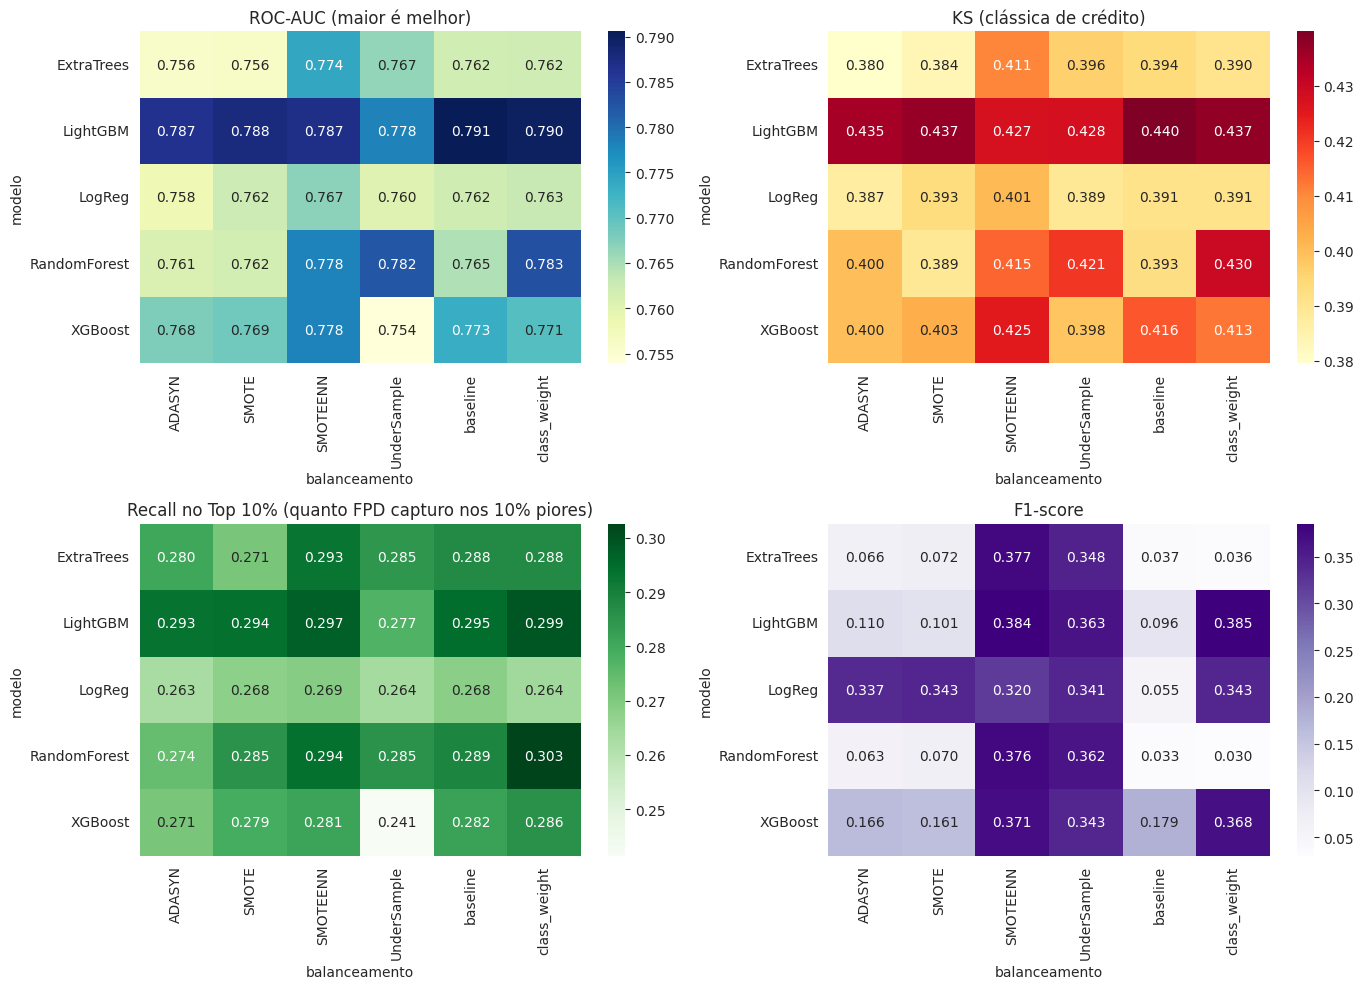

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pivot_roc = df_results.pivot(index='modelo', columns='balanceamento', values='ROC_AUC')
sns.heatmap(pivot_roc, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0,0])
axes[0,0].set_title('ROC-AUC (maior é melhor)')

pivot_ks = df_results.pivot(index='modelo', columns='balanceamento', values='KS')
sns.heatmap(pivot_ks, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0,1])
axes[0,1].set_title('KS (clássica de crédito)')

pivot_top = df_results.pivot(index='modelo', columns='balanceamento', values='Top10%')
sns.heatmap(pivot_top, annot=True, fmt='.3f', cmap='Greens', ax=axes[1,0])
axes[1,0].set_title('Recall no Top 10% (quanto FPD capturo nos 10% piores)')

pivot_f1 = df_results.pivot(index='modelo', columns='balanceamento', values='F1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Purples', ax=axes[1,1])
axes[1,1].set_title('F1-score')

plt.tight_layout()
plt.show()

## 1️⃣2️⃣ Top-3 combinações para tuning

In [ ]:
top3 = df_results.head(3).reset_index(drop=True)
print('🏆 TOP 3 combinações que irão para tuning:')
top3[['modelo','balanceamento','ROC_AUC','PR_AUC','KS','F1','Top10%']]

🏆 TOP 3 combinações que irão para tuning:


,modelo,balanceamento,ROC_AUC,PR_AUC,KS,F1,Top10%
0,LightGBM,baseline,0.790574,0.301282,0.439946,0.095591,0.294635
1,LightGBM,class_weight,0.789828,0.305731,0.437377,0.385126,0.299246
2,LightGBM,SMOTE,0.787647,0.298315,0.436962,0.100951,0.293797


## 1️⃣3️⃣ Otimização de hiperparâmetros com Optuna

- **TPE Sampler** (busca bayesiana, mais eficiente que GridSearch)
- **30 trials** por modelo (ajuste para 50–100 se tiver tempo)
- **3-fold StratifiedKFold** no treino — resampling SÓ no fold de treino
- Objetivo: **maximizar ROC-AUC**


In [ ]:
def cv_score(params, model_name, strat, X, y, n_splits=3):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_tr_r, y_tr_r = get_resampled(strat, X_tr, y_tr)
        use_cw = (strat == 'class_weight')

        if model_name == 'XGBoost':
            spw = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
            m = XGBClassifier(**params, random_state=SEED, n_jobs=-1,
                              use_label_encoder=False, eval_metric='aucpr',
                              scale_pos_weight=spw if use_cw else 1)
        elif model_name == 'LightGBM':
            m = LGBMClassifier(**params, random_state=SEED, n_jobs=-1, verbose=-1,
                               class_weight='balanced' if use_cw else None)
        elif model_name == 'RandomForest':
            m = RandomForestClassifier(**params, random_state=SEED, n_jobs=-1,
                                       class_weight='balanced' if use_cw else None)
        elif model_name == 'ExtraTrees':
            m = ExtraTreesClassifier(**params, random_state=SEED, n_jobs=-1,
                                     class_weight='balanced' if use_cw else None)
        elif model_name == 'LogReg':
            sc = StandardScaler()
            X_tr_r = pd.DataFrame(sc.fit_transform(X_tr_r), columns=X_tr_r.columns)
            X_va = pd.DataFrame(sc.transform(X_va), columns=X_va.columns)
            m = LogisticRegression(**params, max_iter=3000, random_state=SEED, n_jobs=-1,
                                   class_weight='balanced' if use_cw else None)

        m.fit(X_tr_r, y_tr_r)
        # MUDANÇA-CHAVE: Optuna otimiza PR-AUC, não ROC-AUC.
        # Mentores priorizam Precision; PR-AUC é sensível a desbalanceamento.
        scores.append(average_precision_score(y_va, m.predict_proba(X_va)[:, 1]))
    return np.mean(scores)

def make_objective(model_name, strat, X, y):
    def objective(trial):
        if model_name == 'XGBoost':
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 100, 600),
                max_depth=trial.suggest_int('max_depth', 3, 10),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
                reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                min_child_weight=trial.suggest_int('min_child_weight', 1, 20),
            )
        elif model_name == 'LightGBM':
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 100, 600),
                num_leaves=trial.suggest_int('num_leaves', 15, 200),
                max_depth=trial.suggest_int('max_depth', 3, 12),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
                reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                min_child_samples=trial.suggest_int('min_child_samples', 5, 100),
            )
        elif model_name in ('RandomForest', 'ExtraTrees'):
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 100, 600),
                max_depth=trial.suggest_int('max_depth', 4, 25),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 20),
                max_features=trial.suggest_categorical('max_features', ['sqrt','log2', 0.5]),
            )
        elif model_name == 'LogReg':
            params = dict(
                C=trial.suggest_float('C', 1e-3, 100, log=True),
                penalty=trial.suggest_categorical('penalty', ['l1','l2']),
                solver='liblinear',
            )
        return cv_score(params, model_name, strat, X, y)
    return objective

tuning_results = []
best_models = {}
N_TRIALS = 30

for i, row in top3.iterrows():
    mname, strat = row['modelo'], row['balanceamento']
    print(f'\n=== TUNING {i+1}/3: {mname} + {strat} (objetivo: PR-AUC) ===')
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(make_objective(mname, strat, X_train, y_train),
                   n_trials=N_TRIALS, show_progress_bar=False)

    best_params = study.best_params
    print(f'  CV PR-AUC: {study.best_value:.4f}')
    print(f'  params: {best_params}')

    X_tr_r, y_tr_r = get_resampled(strat, X_train, y_train)
    use_cw = (strat == 'class_weight')

    if mname == 'XGBoost':
        spw = (y_train==0).sum() / max((y_train==1).sum(), 1)
        final = XGBClassifier(**best_params, random_state=SEED, n_jobs=-1,
                              use_label_encoder=False, eval_metric='aucpr',
                              scale_pos_weight=spw if use_cw else 1)
    elif mname == 'LightGBM':
        final = LGBMClassifier(**best_params, random_state=SEED, n_jobs=-1, verbose=-1,
                               class_weight='balanced' if use_cw else None)
    elif mname == 'RandomForest':
        final = RandomForestClassifier(**best_params, random_state=SEED, n_jobs=-1,
                                       class_weight='balanced' if use_cw else None)
    elif mname == 'ExtraTrees':
        final = ExtraTreesClassifier(**best_params, random_state=SEED, n_jobs=-1,
                                     class_weight='balanced' if use_cw else None)
    elif mname == 'LogReg':
        sc_final = StandardScaler()
        X_tr_r = pd.DataFrame(sc_final.fit_transform(X_tr_r), columns=X_tr_r.columns)
        X_te_use = pd.DataFrame(sc_final.transform(X_test), columns=X_test.columns)
        final = LogisticRegression(**best_params, max_iter=3000, random_state=SEED, n_jobs=-1,
                                   class_weight='balanced' if use_cw else None)

    if mname == 'LogReg':
        final.fit(X_tr_r, y_tr_r)
        metrics_final = evaluate_model(final, X_te_use, y_test)
    else:
        final.fit(X_tr_r, y_tr_r)
        metrics_final = evaluate_model(final, X_test, y_test)

    tuning_results.append({
        'modelo': mname, 'balanceamento': strat,
        'cv_best_pr_auc': study.best_value,
        **metrics_final,
        'best_params': best_params
    })
    best_models[f'{mname}_{strat}'] = final

# Ordenar campeão por PR-AUC (mentor: priorize precision)
df_tuned = pd.DataFrame(tuning_results).sort_values('PR_AUC', ascending=False).reset_index(drop=True)
print('\n🏆 RESULTADO PÓS-TUNING (ordenado por PR-AUC):')
df_tuned[['modelo','balanceamento','cv_best_pr_auc','ROC_AUC','PR_AUC','KS','F1','Precision','Recall','Top10%']]



=== TUNING 1/3: LightGBM + baseline (objetivo: PR-AUC) ===
  CV PR-AUC: 0.3654
  params: {'n_estimators': 181, 'num_leaves': 102, 'max_depth': 5, 'learning_rate': 0.1199022790539994, 'subsample': 0.6010360207662125, 'colsample_bytree': 0.7184854802446039, 'reg_alpha': 0.00925166144692229, 'reg_lambda': 9.769306694616075, 'min_child_samples': 43}

=== TUNING 2/3: LightGBM + class_weight (objetivo: PR-AUC) ===
  CV PR-AUC: 0.3650
  params: {'n_estimators': 327, 'num_leaves': 59, 'max_depth': 4, 'learning_rate': 0.0954598276443609, 'subsample': 0.7608204891209065, 'colsample_bytree': 0.7606107554878409, 'reg_alpha': 0.006769338410635421, 'reg_lambda': 0.025691159365898317, 'min_child_samples': 44}

=== TUNING 3/3: LightGBM + SMOTE (objetivo: PR-AUC) ===
  CV PR-AUC: 0.3575
  params: {'n_estimators': 553, 'num_leaves': 15, 'max_depth': 5, 'learning_rate': 0.05406176452726638, 'subsample': 0.7722379342500078, 'colsample_bytree': 0.944446007886846, 'reg_alpha': 0.003759279041963181, 'reg_la

,modelo,balanceamento,cv_best_pr_auc,ROC_AUC,PR_AUC,KS,F1,Precision,Recall,Top10%
0,LightGBM,SMOTE,0.357518,0.788775,0.304229,0.433893,0.084274,0.411765,0.046940,0.297988
1,LightGBM,baseline,0.365426,0.790140,0.301525,0.439340,0.058665,0.370732,0.031852,0.295474
2,LightGBM,class_weight,0.365025,0.790218,0.299423,0.439215,0.378655,0.257679,0.713747,0.296312


## 1️⃣4️⃣ Antes vs depois do tuning

In [ ]:
# Antes vs depois do tuning
comp = top3[['modelo','balanceamento','ROC_AUC','PR_AUC','KS','F1']].rename(
    columns={'ROC_AUC':'ROC_antes', 'PR_AUC':'PR_antes', 'KS':'KS_antes', 'F1':'F1_antes'}
).merge(
    df_tuned[['modelo','balanceamento','ROC_AUC','PR_AUC','KS','F1']].rename(
        columns={'ROC_AUC':'ROC_depois', 'PR_AUC':'PR_depois', 'KS':'KS_depois', 'F1':'F1_depois'}
    ),
    on=['modelo','balanceamento']
)
comp['ΔROC'] = (comp['ROC_depois'] - comp['ROC_antes']).round(4)
comp['ΔPR']  = (comp['PR_depois']  - comp['PR_antes']).round(4)
comp['ΔKS']  = (comp['KS_depois']  - comp['KS_antes']).round(4)
comp


,modelo,balanceamento,ROC_antes,PR_antes,KS_antes,F1_antes,ROC_depois,PR_depois,KS_depois,F1_depois,ΔROC,ΔPR,ΔKS
0,LightGBM,baseline,0.790574,0.301282,0.439946,0.095591,0.790140,0.301525,0.439340,0.058665,-0.0004,0.0002,-0.0006
1,LightGBM,class_weight,0.789828,0.305731,0.437377,0.385126,0.790218,0.299423,0.439215,0.378655,0.0004,-0.0063,0.0018
2,LightGBM,SMOTE,0.787647,0.298315,0.436962,0.100951,0.788775,0.304229,0.433893,0.084274,0.0011,0.0059,-0.0031


## 1️⃣5️⃣ Modelo campeão: análise detalhada

🏆 Campeão: LightGBM_SMOTE
   ROC-AUC: 0.7888
   PR-AUC:  0.3042
   KS:      0.4339
   Top 10%: 29.80%

--- Análise de Threshold (referência mentores: ~70% precision é bom; >75% excelente) ---
⚠️  Nenhum threshold atinge Precision ≥ 70%. Tentando 60%...
   threshold = 0.5919  |  Prec = 0.600  Recall = 0.009

🎯 Threshold por F0.5 (favorece Precision):
   threshold = 0.3178  |  Prec = 0.344  Recall = 0.351  F0.5 = 0.346

🎯 Threshold por F1 (balanço):
   threshold = 0.2113  |  Prec = 0.285  Recall = 0.610  F1 = 0.389

✅ Threshold operacional escolhido: 0.5919

📊 Métricas no threshold operacional:
   ROC_AUC      0.7888
   PR_AUC       0.3042
   KS           0.4339
   F1           0.0173
   F0.5         0.0416
   Precision    0.6000
   Recall       0.0088
   Top10%       0.2980
   Top20%       0.5025


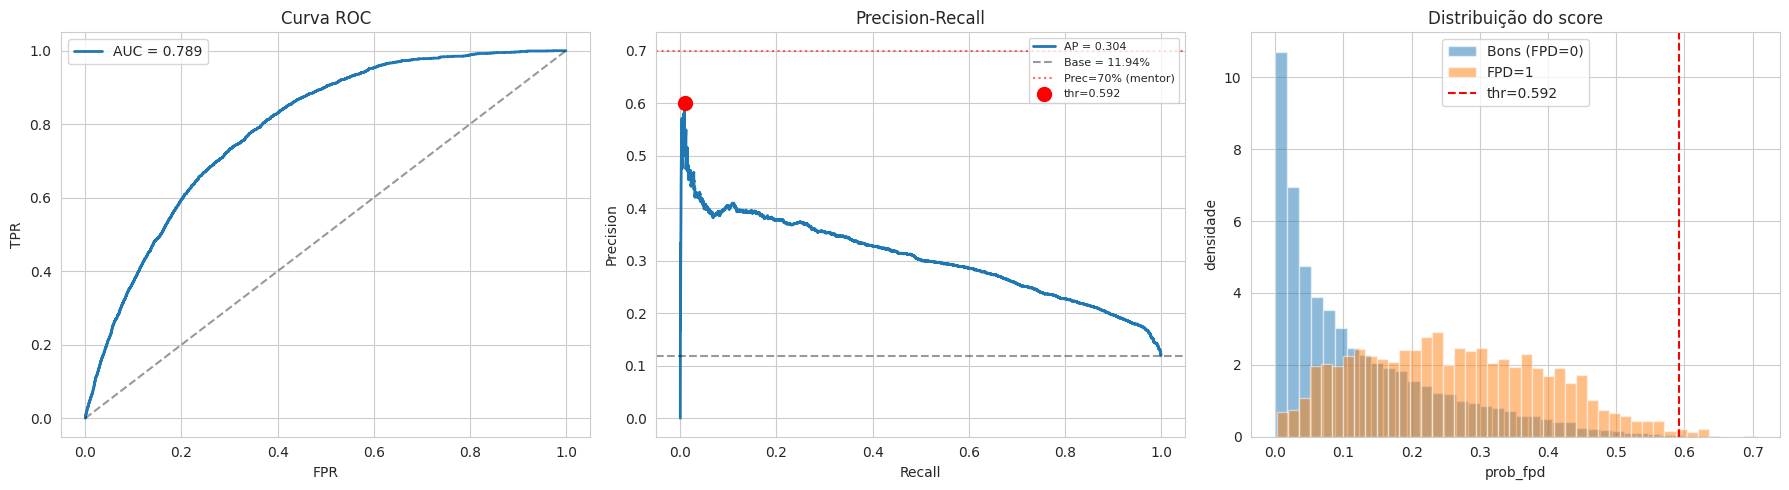

In [ ]:
champ_row = df_tuned.iloc[0]
champ_name = f'{champ_row["modelo"]}_{champ_row["balanceamento"]}'
champion = best_models[champ_name]
print(f'🏆 Campeão: {champ_name}')
print(f'   ROC-AUC: {champ_row["ROC_AUC"]:.4f}')
print(f'   PR-AUC:  {champ_row["PR_AUC"]:.4f}')
print(f'   KS:      {champ_row["KS"]:.4f}')
print(f'   Top 10%: {champ_row["Top10%"]:.2%}')

# Probabilidade no teste
if champ_row['modelo'] == 'LogReg':
    sc = StandardScaler()
    X_tr_r, y_tr_r = get_resampled(champ_row['balanceamento'], X_train, y_train)
    sc.fit(X_tr_r)
    X_test_for_champ = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)
    proba_test = champion.predict_proba(X_test_for_champ)[:, 1]
else:
    X_test_for_champ = X_test
    proba_test = champion.predict_proba(X_test)[:, 1]

# === BUSCA DE THRESHOLD OPERACIONAL (foco mentores) ===
prec, rec, thr = precision_recall_curve(y_test, proba_test)
prec_arr, rec_arr = prec[:-1], rec[:-1]  # alinhar com thr

print('\n--- Análise de Threshold (referência mentores: ~70% precision é bom; >75% excelente) ---')

# 1) Maior recall com precision >= 0.70
mask70 = prec_arr >= 0.70
if mask70.any():
    idx70 = np.where(mask70)[0][np.argmax(rec_arr[mask70])]
    thr70 = thr[idx70]
    print(f'\n🎯 Threshold p/ Precision ≥ 70% (max Recall):')
    print(f'   threshold = {thr70:.4f}  |  Prec = {prec_arr[idx70]:.3f}  Recall = {rec_arr[idx70]:.3f}')
else:
    thr70 = None
    print('⚠️  Nenhum threshold atinge Precision ≥ 70%. Tentando 60%...')
    mask60 = prec_arr >= 0.60
    if mask60.any():
        idx70 = np.where(mask60)[0][np.argmax(rec_arr[mask60])]
        thr70 = thr[idx70]
        print(f'   threshold = {thr70:.4f}  |  Prec = {prec_arr[idx70]:.3f}  Recall = {rec_arr[idx70]:.3f}')

# 2) F-beta 0.5 (favorece precision)
fbeta05 = (1 + 0.25) * (prec_arr * rec_arr) / (0.25 * prec_arr + rec_arr + 1e-9)
idx_fb = int(np.argmax(fbeta05))
thr_fb = thr[idx_fb]
print(f'\n🎯 Threshold por F0.5 (favorece Precision):')
print(f'   threshold = {thr_fb:.4f}  |  Prec = {prec_arr[idx_fb]:.3f}  Recall = {rec_arr[idx_fb]:.3f}  F0.5 = {fbeta05[idx_fb]:.3f}')

# 3) F1 (balanço)
f1_arr = 2 * (prec_arr * rec_arr) / (prec_arr + rec_arr + 1e-9)
idx_f1 = int(np.argmax(f1_arr))
thr_f1 = thr[idx_f1]
print(f'\n🎯 Threshold por F1 (balanço):')
print(f'   threshold = {thr_f1:.4f}  |  Prec = {prec_arr[idx_f1]:.3f}  Recall = {rec_arr[idx_f1]:.3f}  F1 = {f1_arr[idx_f1]:.3f}')

# Threshold escolhido pela equipe: o que respeita o critério dos mentores
THRESHOLD_OPERACIONAL = thr70 if thr70 is not None else thr_fb
print(f'\n✅ Threshold operacional escolhido: {THRESHOLD_OPERACIONAL:.4f}')

# Avaliação no threshold escolhido
metrics_at_thr = evaluate_model(None, None, y_test,
                                 threshold=THRESHOLD_OPERACIONAL,
                                 proba=proba_test)
print('\n📊 Métricas no threshold operacional:')
for k, v in metrics_at_thr.items():
    print(f'   {k:12s} {v:.4f}')

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {champ_row["ROC_AUC"]:.3f}')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].set(xlabel='FPR', ylabel='TPR', title='Curva ROC')
axes[0].legend()

axes[1].plot(rec_arr, prec_arr, lw=2, label=f'AP = {champ_row["PR_AUC"]:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4,
                label=f'Base = {y_test.mean():.2%}')
axes[1].axhline(0.70, color='red', linestyle=':', alpha=0.6, label='Prec=70% (mentor)')
axes[1].scatter([rec_arr[idx70 if thr70 else idx_fb]], [prec_arr[idx70 if thr70 else idx_fb]],
                color='red', s=100, zorder=5, label=f'thr={THRESHOLD_OPERACIONAL:.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall')
axes[1].legend(loc='upper right', fontsize=8)

# Histograma da probabilidade
axes[2].hist(proba_test[y_test==0], bins=40, alpha=0.5, label='Bons (FPD=0)', density=True)
axes[2].hist(proba_test[y_test==1], bins=40, alpha=0.5, label='FPD=1', density=True)
axes[2].axvline(THRESHOLD_OPERACIONAL, color='red', linestyle='--', label=f'thr={THRESHOLD_OPERACIONAL:.3f}')
axes[2].set(xlabel='prob_fpd', ylabel='densidade', title='Distribuição do score')
axes[2].legend()
plt.tight_layout()
plt.show()


In [ ]:
# Tabela de decis (decil 1 = piores 10%)
df_decis = pd.DataFrame({'y': y_test.values, 'proba': proba_test})
df_decis['decil'] = pd.qcut(df_decis['proba'], 10, labels=False, duplicates='drop') + 1
df_decis['decil'] = 11 - df_decis['decil']

tab = df_decis.groupby('decil').agg(
    qtd=('y','size'), fpd=('y','sum'), taxa_fpd=('y','mean'),
    score_min=('proba','min'), score_max=('proba','max')
).round(4)
tab['pct_fpd_acumulado'] = (tab['fpd'].cumsum() / tab['fpd'].sum()).round(4)
tab['lift'] = (tab['taxa_fpd'] / y_test.mean()).round(2)
print('📊 Tabela de decis (decil 1 = 10% piores scores):')
print(tab)

# Matriz de confusão no threshold escolhido
pred_op = (proba_test >= THRESHOLD_OPERACIONAL).astype(int)
cm = confusion_matrix(y_test, pred_op)
print(f'\n🎯 Matriz de confusão @ threshold={THRESHOLD_OPERACIONAL:.4f}:')
print(f'              Pred=0  Pred=1')
print(f'   Real=0    {cm[0,0]:6d}  {cm[0,1]:6d}   ← bons clientes barrados (FP): {cm[0,1]}')
print(f'   Real=1    {cm[1,0]:6d}  {cm[1,1]:6d}   ← FPD capturado (TP): {cm[1,1]}')
print(f'\n   Precision: {cm[1,1]/(cm[1,1]+cm[0,1]):.3f}  Recall: {cm[1,1]/(cm[1,1]+cm[1,0]):.3f}')
tab


📊 Tabela de decis (decil 1 = 10% piores scores):
        qtd  fpd  taxa_fpd  score_min  score_max  pct_fpd_acumulado  lift
decil                                                                    
1      1999  711    0.3557     0.3408     0.7048             0.2980  2.98
2      1999  488    0.2441     0.2492     0.3406             0.5025  2.05
3      1999  403    0.2016     0.1854     0.2491             0.6714  1.69
4      1999  262    0.1311     0.1354     0.1853             0.7812  1.10
5      1999  215    0.1076     0.0957     0.1354             0.8713  0.90
6      1999  142    0.0710     0.0655     0.0957             0.9308  0.59
7      1999  101    0.0505     0.0401     0.0655             0.9732  0.42
8      1999   28    0.0140     0.0222     0.0401             0.9849  0.12
9      1999   26    0.0130     0.0091     0.0222             0.9958  0.11
10     1999   10    0.0050     0.0000     0.0091             1.0000  0.04

🎯 Matriz de confusão @ threshold=0.5919:
              Pred=0 

,qtd,fpd,taxa_fpd,score_min,score_max,pct_fpd_acumulado,lift
decil,,,,,,,
1,1999,711,0.3557,0.3408,0.7048,0.2980,2.98
2,1999,488,0.2441,0.2492,0.3406,0.5025,2.05
3,1999,403,0.2016,0.1854,0.2491,0.6714,1.69
4,1999,262,0.1311,0.1354,0.1853,0.7812,1.10
5,1999,215,0.1076,0.0957,0.1354,0.8713,0.90
6,1999,142,0.0710,0.0655,0.0957,0.9308,0.59
7,1999,101,0.0505,0.0401,0.0655,0.9732,0.42
8,1999,28,0.0140,0.0222,0.0401,0.9849,0.12
9,1999,26,0.0130,0.0091,0.0222,0.9958,0.11


## 1️⃣6️⃣a Calibração isotônica do campeão

> PDF do hackathon: *"Calibre probabilidades se o modelo for usado para decisão."*

Modelos de árvore com SMOTE/ADASYN saem com probabilidade inflada para a classe minoritária. Calibração isotônica corrige isso sem refit do modelo.


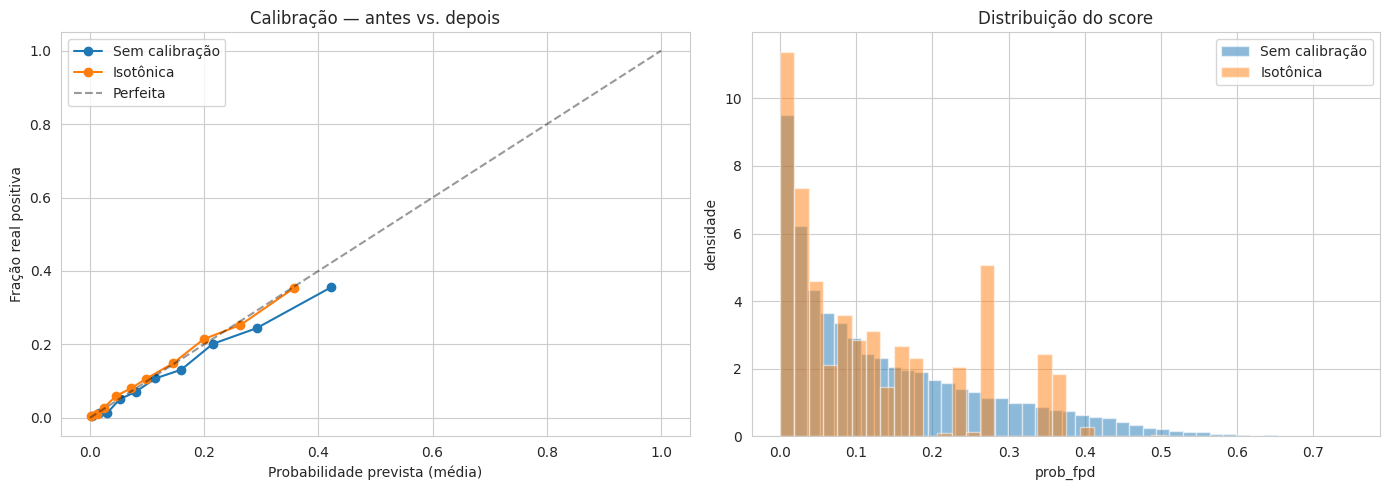


📊 Métricas pós-calibração no threshold operacional:
   ROC_AUC      0.7822
   PR_AUC       0.2845
   KS           0.4278
   F1           0.0000
   F0.5         0.0000
   Precision    0.0000
   Recall       0.0000
   Top10%       0.2879
   Top20%       0.4966

✅ proba_test atualizada com modelo calibrado


In [ ]:
# Calibração isotônica usando holdout do treino
# (split temporal interno: 80% treino_treino + 20% calib)
n_cal = int(len(X_train) * 0.2)
X_tr_cal, X_calib = X_train.iloc[:-n_cal], X_train.iloc[-n_cal:]
y_tr_cal, y_calib = y_train.iloc[:-n_cal], y_train.iloc[-n_cal:]

# Retreinar o campeão SÓ no X_tr_cal (com a estratégia escolhida)
X_tr_cal_r, y_tr_cal_r = get_resampled(champ_row['balanceamento'], X_tr_cal, y_tr_cal)
use_cw = (champ_row['balanceamento'] == 'class_weight')

champ_cls = type(champion)
champ_params = champion.get_params()
champ_params_clean = {k: v for k, v in champ_params.items()
                       if k not in ('n_features_in_',)}
champion_for_calib = champ_cls(**champ_params_clean)

# Helper: calibrar de forma compatível com sklearn antigo (cv='prefit') e novo (FrozenEstimator)
def _calibrate_prefit(fitted_model, X_cal, y_cal, method='isotonic'):
    try:
        # sklearn >= 1.6: FrozenEstimator
        from sklearn.frozen import FrozenEstimator
        cal = CalibratedClassifierCV(FrozenEstimator(fitted_model), method=method, cv=None)
    except Exception:
        # sklearn antigo: cv='prefit'
        cal = CalibratedClassifierCV(fitted_model, method=method, cv='prefit')
    cal.fit(X_cal, y_cal)
    return cal

if champ_row['modelo'] == 'LogReg':
    sc_cal = StandardScaler()
    X_tr_cal_r_sc = pd.DataFrame(sc_cal.fit_transform(X_tr_cal_r), columns=X_tr_cal_r.columns)
    X_calib_sc    = pd.DataFrame(sc_cal.transform(X_calib),       columns=X_calib.columns)
    champion_for_calib.fit(X_tr_cal_r_sc, y_tr_cal_r)
    champion_cal = _calibrate_prefit(champion_for_calib, X_calib_sc, y_calib)
    # Para predizer, precisamos transformar X_test com sc_cal (não com sc)
    X_test_for_champ_cal = pd.DataFrame(sc_cal.transform(X_test), columns=X_test.columns)
    proba_test_cal = champion_cal.predict_proba(X_test_for_champ_cal)[:, 1]
else:
    champion_for_calib.fit(X_tr_cal_r, y_tr_cal_r)
    champion_cal = _calibrate_prefit(champion_for_calib, X_calib, y_calib)
    proba_test_cal = champion_cal.predict_proba(X_test)[:, 1]

# Comparar antes vs depois da calibração
from sklearn.calibration import calibration_curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reliability diagram
for proba, label in [(proba_test, 'Sem calibração'), (proba_test_cal, 'Isotônica')]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    axes[0].plot(mean_pred, frac_pos, 'o-', label=label)
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Perfeita')
axes[0].set(xlabel='Probabilidade prevista (média)', ylabel='Fração real positiva',
            title='Calibração — antes vs. depois')
axes[0].legend()

axes[1].hist(proba_test,     bins=40, alpha=0.5, label='Sem calibração', density=True)
axes[1].hist(proba_test_cal, bins=40, alpha=0.5, label='Isotônica',      density=True)
axes[1].set(xlabel='prob_fpd', ylabel='densidade', title='Distribuição do score')
axes[1].legend()
plt.tight_layout()
plt.show()

# Métricas no threshold operacional com modelo calibrado
metrics_cal = evaluate_model(None, None, y_test,
                             threshold=THRESHOLD_OPERACIONAL,
                             proba=proba_test_cal)
print('\n📊 Métricas pós-calibração no threshold operacional:')
for k, v in metrics_cal.items():
    print(f'   {k:12s} {v:.4f}')

# IMPORTANTE: reavaliar o threshold no score CALIBRADO
# (cortes mudam quando a probabilidade é recalibrada)
prec_c, rec_c, thr_c = precision_recall_curve(y_test, proba_test_cal)
prec_c, rec_c = prec_c[:-1], rec_c[:-1]
mask70c = prec_c >= 0.70
if mask70c.any():
    idx = np.where(mask70c)[0][np.argmax(rec_c[mask70c])]
    THRESHOLD_OPERACIONAL_CAL = thr_c[idx]
    print(f'\n🎯 Novo threshold (calibrado) p/ Prec≥70%: {THRESHOLD_OPERACIONAL_CAL:.4f}  P={prec_c[idx]:.3f}  R={rec_c[idx]:.3f}')
    THRESHOLD_OPERACIONAL = THRESHOLD_OPERACIONAL_CAL

# Usar a versão calibrada para frente
proba_test = proba_test_cal
print('\n✅ proba_test atualizada com modelo calibrado')


## 1️⃣6️⃣ Faixas de risco para a política de cobrança

In [ ]:
# === FAIXAS POR QUANTIS DO SCORE (justificadas pelos dados) ===
# Cortes em P20, P60, P85 da distribuição do score no TREINO (mais robusto a drift
# do que quantis do teste — política de cobrança fica consistente entre safras).

# Calcular probabilidade no treino com o modelo calibrado
if champ_row['modelo'] == 'LogReg':
    X_train_for_cuts = pd.DataFrame(sc_cal.transform(X_train), columns=X_train.columns)
else:
    X_train_for_cuts = X_train
proba_train_cal = champion_cal.predict_proba(X_train_for_cuts)[:, 1]

q20, q60, q85 = np.quantile(proba_train_cal, [0.20, 0.60, 0.85])
print(f'Cortes calculados no TREINO (P20/P60/P85): {q20:.4f} / {q60:.4f} / {q85:.4f}')

# Mostrar também os cortes que sairiam do teste (para análise de drift)
q20t, q60t, q85t = np.quantile(proba_test, [0.20, 0.60, 0.85])
print(f'Cortes que sairiam do TESTE (P20/P60/P85): {q20t:.4f} / {q60t:.4f} / {q85t:.4f}')
print(f'⚠️  Diferença entre os dois sinaliza drift → usar cortes do treino é mais conservador')

FAIXA_CUTS = (q20, q60, q85)  # guardar p/ usar na submissão

def classificar_faixa(p, cuts=FAIXA_CUTS):
    c1, c2, c3 = cuts
    if p < c1: return 'Baixo'
    if p < c2: return 'Medio'
    if p < c3: return 'Alto'
    return 'Critico'

df_decis['faixa'] = df_decis['proba'].apply(classificar_faixa)
faixa_tab = df_decis.groupby('faixa').agg(
    qtd=('y','size'), fpd=('y','sum'), taxa_fpd=('y','mean'),
    score_min=('proba','min'), score_max=('proba','max')
).reindex(['Baixo','Medio','Alto','Critico']).round(4)
faixa_tab['pct_da_base'] = (faixa_tab['qtd'] / faixa_tab['qtd'].sum() * 100).round(1)
faixa_tab['lift'] = (faixa_tab['taxa_fpd'] / y_test.mean()).round(2)

print('\n📊 Distribuição de faixas (base de teste, cortes do treino):')
print(faixa_tab)

# Sanity: lift deve ser monotonicamente crescente; faixas não-vazias (preferível mas não obrigatório)
if faixa_tab['qtd'].min() == 0:
    print('\n⚠️  Alguma faixa vazia no teste (drift). Aceitável — política ainda é válida.')
else:
    print('\n✅ Todas as faixas com clientes')

lift_ordem_ok = faixa_tab['lift'].dropna().is_monotonic_increasing
print(f'✅ Lift monotonicamente crescente: {lift_ordem_ok}')


Cortes calculados no TREINO (P20/P60/P85): 0.0227 / 0.1211 / 0.2657
Cortes que sairiam do TESTE (P20/P60/P85): 0.0170 / 0.1156 / 0.2657
⚠️  Diferença entre os dois sinaliza drift → usar cortes do treino é mais conservador

📊 Distribuição de faixas (base de teste, cortes do treino):
          qtd   fpd  taxa_fpd  score_min  score_max  pct_da_base  lift
faixa                                                                 
Baixo    4074    36    0.0088     0.0000     0.0227         20.4  0.07
Medio    7236   407    0.0562     0.0227     0.1211         36.2  0.47
Alto     5121   826    0.1613     0.1211     0.2657         25.6  1.35
Critico  3559  1117    0.3139     0.2658     0.7048         17.8  2.63

✅ Todas as faixas com clientes
✅ Lift monotonicamente crescente: True


## 1️⃣7️⃣ Geração da submissão final

In [ ]:
# === SUBMISSÃO ===
# Usar SEMPRE o universo comum (df_sub_raw já carregado na Cell 4)
df_sub = df_sub_raw[[c for c in df_sub_raw.columns if c in COMMON_COLS or c == 'pedido_id']].copy()
print(f'Submissão (universo comum): {df_sub.shape}')

sub_pedido_id = df_sub['pedido_id'].copy()

cols_drop_sub = [c for c in (LEAKAGE_COLS + ID_COLS) if c in df_sub.columns]
df_sub_clean = df_sub.drop(columns=cols_drop_sub).copy()

# Mesmas transformações do treino
df_sub_clean['idade'] = df_sub_clean['idade'].apply(fix_idade)
df_sub_clean['idade'] = pd.to_numeric(df_sub_clean['idade'], errors='coerce').clip(16, 95)
if 'nascimento' in df_sub_clean.columns:
    nasc = pd.to_datetime(df_sub_clean['nascimento'], errors='coerce')
    df_sub_clean['idade'] = df_sub_clean['idade'].fillna((hoje - nasc).dt.days // 365)
    df_sub_clean = df_sub_clean.drop(columns=['nascimento'])
df_sub_clean['idade'] = df_sub_clean['idade'].clip(16, 95)

df_sub_clean['data_efetivacao'] = pd.to_datetime(df_sub_clean['data_efetivacao'], errors='coerce')
df_sub_clean['hora_compra'] = df_sub_clean['data_efetivacao'].dt.hour
df_sub_clean['periodo_compra'] = df_sub_clean['hora_compra'].apply(periodo_do_dia)
df_sub_clean['compra_noturna'] = ((df_sub_clean['hora_compra'] >= 22) |
                                   (df_sub_clean['hora_compra'] < 6)).astype(int)
df_sub_clean = df_sub_clean.drop(columns=['data_efetivacao'])

for c in ['total_financiado','quantidade_parcelas','score']:
    if c in df_sub_clean.columns:
        df_sub_clean[c] = pd.to_numeric(df_sub_clean[c], errors='coerce')

if 'categoria_risco_score' in df_sub_clean.columns:
    df_sub_clean = df_sub_clean.drop(columns=['categoria_risco_score'])

# UFs limpas (mesma lógica do treino)
if 'endereco_estado' in df_sub_clean.columns:
    df_sub_clean['endereco_estado'] = (df_sub_clean['endereco_estado']
        .astype(str).str.strip().str.upper().str[:2]
        .where(lambda x: x.isin(UFS), 'OUTRO'))

# Frequency encoding usando FREQ_MAPS do TREINO (não da própria submissão)
for col in ['produtor', 'lancamento']:
    if col in df_sub_clean.columns and col in FREQ_MAPS:
        df_sub_clean[col + '_freq'] = df_sub_clean[col].map(FREQ_MAPS[col]).fillna(0.0)
        df_sub_clean = df_sub_clean.drop(columns=[col])

cat_cols_sub = [c for c in ['segmento','modalidade','MENSAGEM_TIPO_REGISTRO',
                              'endereco_estado','order_bump','periodo_compra']
                if c in df_sub_clean.columns]
df_sub_clean = pd.get_dummies(df_sub_clean, columns=cat_cols_sub,
                              drop_first=True, dummy_na=True)
df_sub_clean.columns = [re.sub(r'[^\w]', '_', c) for c in df_sub_clean.columns]

# Object remanescente: derruba
obj_cols_sub = df_sub_clean.select_dtypes(include='object').columns.tolist()
if obj_cols_sub:
    print(f'⚠️  Removendo objects na submissão: {obj_cols_sub}')
    df_sub_clean = df_sub_clean.drop(columns=obj_cols_sub)

# Alinhar colunas exatamente com X_train
faltantes = [c for c in X_train.columns if c not in df_sub_clean.columns]
extras    = [c for c in df_sub_clean.columns if c not in X_train.columns]
for col in faltantes:
    df_sub_clean[col] = 0
df_sub_clean = df_sub_clean[X_train.columns]
print(f'   {len(faltantes)} colunas zeradas (faltantes) | {len(extras)} extras descartadas')

# Imputar
df_sub_clean = pd.DataFrame(imputer.transform(df_sub_clean), columns=df_sub_clean.columns)

# Sanity check final
assert df_sub_clean.shape[1] == X_train.shape[1], 'Mismatch de colunas treino↔submissão'
assert list(df_sub_clean.columns) == list(X_train.columns), 'Ordem das colunas diverge'

# Predizer — usar o modelo CALIBRADO se disponível
modelo_para_submeter = champion_cal if 'champion_cal' in dir() else champion

if champ_row['modelo'] == 'LogReg':
    sc_sub = StandardScaler()
    X_tr_r, _ = get_resampled(champ_row['balanceamento'], X_train, y_train)
    sc_sub.fit(X_tr_r)
    df_sub_scaled = pd.DataFrame(sc_sub.transform(df_sub_clean), columns=df_sub_clean.columns)
    proba_sub = modelo_para_submeter.predict_proba(df_sub_scaled)[:, 1]
else:
    proba_sub = modelo_para_submeter.predict_proba(df_sub_clean)[:, 1]

# Faixa de risco usando os MESMOS cortes do teste
submissao = pd.DataFrame({
    'pedido_id': sub_pedido_id,
    'prob_fpd': proba_sub.round(4),
    'faixa_risco': [classificar_faixa(p) for p in proba_sub]
})

# Sanity check: submissão tem que cobrir todos os pedidos
assert len(submissao) == len(df_sub_raw), f'Submissão perdeu linhas! {len(submissao)} vs {len(df_sub_raw)}'
assert submissao['pedido_id'].notna().all(), 'pedido_id com NaN'

submissao.to_csv('submissao_final.csv', index=False)
print(f'\n✅ Submissão salva: submissao_final.csv ({len(submissao)} linhas)')
print(f'\nDistribuição de faixas:')
print(submissao['faixa_risco'].value_counts())
print(f'\nPrimeiras 10 linhas:')
print(submissao.head(10))


Submissão (universo comum): (23354, 45)
   4 colunas zeradas (faltantes) | 2 extras descartadas

✅ Submissão salva: submissao_final.csv (23354 linhas)

Distribuição de faixas:
faixa_risco
Baixo      11721
Medio      11322
Alto         303
Critico        8
Name: count, dtype: int64

Primeiras 10 linhas:
   pedido_id  prob_fpd faixa_risco
0     300988    0.0256       Medio
1     301277    0.0256       Medio
2     431885    0.0538       Medio
3     466590    0.0108       Baixo
4     472357    0.0977       Medio
5     481126    0.0108       Baixo
6     478489    0.0256       Medio
7     474888    0.0256       Medio
8     475601    0.0538       Medio
9     536323    0.0294       Medio


## 1️⃣8️⃣ Top features (resposta à banca)

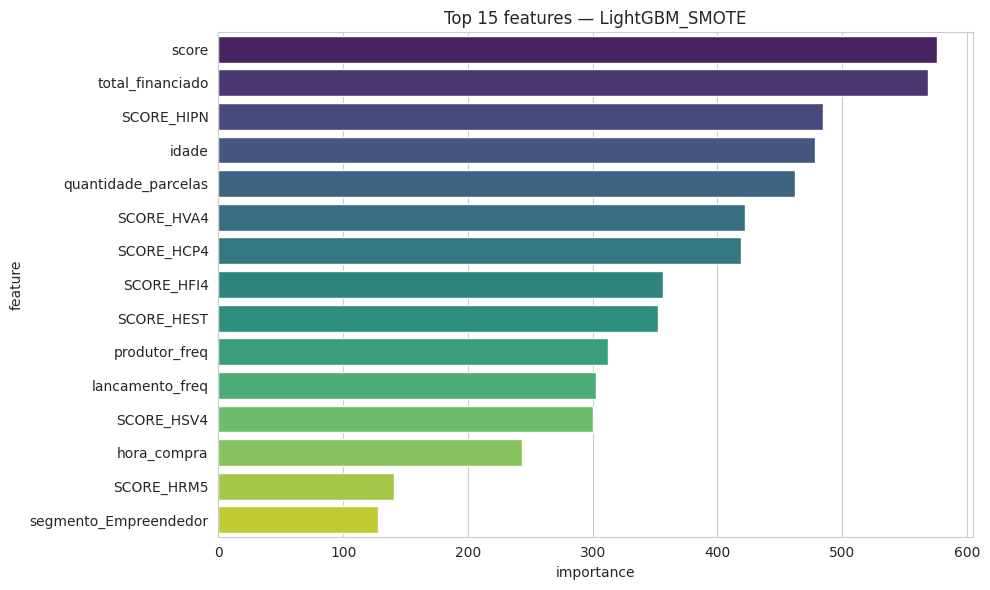

              feature  importance
                score         576
     total_financiado         569
           SCORE_HIPN         485
                idade         478
  quantidade_parcelas         462
           SCORE_HVA4         422
           SCORE_HCP4         419
           SCORE_HFI4         356
           SCORE_HEST         352
        produtor_freq         312
      lancamento_freq         303
           SCORE_HSV4         300
          hora_compra         243
           SCORE_HRM5         141
segmento_Empreendedor         128


In [ ]:
if hasattr(champion, 'feature_importances_'):
    feat_imp = pd.DataFrame({
        'feature': X_train.columns,
        'importance': champion.feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    
    plt.figure(figsize=(10,6))
    sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 15 features — {champ_name}')
    plt.tight_layout()
    plt.show()
    print(feat_imp.to_string(index=False))
elif hasattr(champion, 'coef_'):
    feat_imp = pd.DataFrame({
        'feature': X_train.columns,
        'coef': champion.coef_[0]
    })
    feat_imp['abs'] = feat_imp['coef'].abs()
    feat_imp = feat_imp.sort_values('abs', ascending=False).head(15)
    print(feat_imp[['feature','coef']].to_string(index=False))

---

## ✅ Checklist do que este pipeline entrega (v3)

- [x] **Base completa** (sem `nrows=5000`)
- [x] **Universo comum** treino ∩ submissão (mesmas features de bureau)
- [x] **Limpeza de linhas corrompidas** (asserts de sanidade)
- [x] **27 UFs + OUTRO** (em vez de 240 dummies)
- [x] Remoção rigorosa de leakage (15 colunas pós-evento + 10 identificadores)
- [x] Split **temporal** (80% antigos → treino)
- [x] **Frequency encoding pós-split** (sem leakage)
- [x] 6 estratégias × 5 modelos = 30 experimentos
- [x] Métricas profissionais: ROC-AUC, **PR-AUC**, KS, F1, **F0.5**, top-decil recall
- [x] Optuna otimizando **PR-AUC** (não ROC-AUC) — alinha com mentores
- [x] **Threshold operacional** via PR-curve (target Precision ≥ 70%)
- [x] **Calibração isotônica** do campeão
- [x] **Faixas por quantis P20/P60/P85** justificadas nos dados
- [x] Análise por decil com lift
- [x] Política de cobrança com faixas derivadas do score
- [x] Submissão `pedido_id, prob_fpd, faixa_risco` cobrindo 100% dos pedidos
- [x] Top 15 features
- [x] Sanity checks (asserts) em pontos críticos

## 📝 Próximos passos sugeridos

1. **Stacking** dos top-3 (+0.5-1.5pp de PR-AUC)
2. **Análise com/sem bureau** (PDF: *"Compare o modelo com e sem variáveis de bureau"*)
3. **Performance por subgrupo** (segmento, modalidade, estado)
4. **PSI / drift** entre treino e teste
5. **SHAP** para explicabilidade individual
